In [1]:
pip install langgraph==1.1.6

In [2]:
pip install langchain-openai==1.1.13

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.7/508.7 kB 13.0 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.28
    Uninstalling langchain-core-1.2.28:
      Successfully uninstalled langchain-core-1.2.28


In [3]:
pip install langchain-community==0.4.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [4]:
pip show langgraph langchain-openai langchain-community

Name: langgraph
Version: 1.1.6
Summary: Building stateful, multi-actor applications with LLMs
Home-page: https://docs.langchain.com/oss/python/langgraph/overview
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, langgraph-checkpoint, langgraph-prebuilt, langgraph-sdk, pydantic, xxhash
Required-by: langchain
---
Name: langchain-openai
Version: 1.1.13
Summary: An integration package connecting OpenAI and LangChain
Home-page: https://docs.langchain.com/oss/python/integrations/providers/openai
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, openai, tiktoken
Required-by: 
---
Name: langchain-community
Version: 0.4.1
Summary: Community contributed LangChain integrations.
Home-page: 
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: aiohttp, dataclasses-json, httpx-sse, langchain-classic, langchain-core, langsmith, numpy, p

In [5]:
import os
from google.colab import userdata

# Retrieve the API key from Colab secrets
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

os.environ["TAVILY_API_KEY"] = userdata.get("TAVILY_API_KEY")

# You can verify it's set (for demonstration, avoid printing actual key in production)
# print(os.environ.get("OPENAI_API_KEY"))
print("OpenAI API key and Tavily API key loaded into environment variable.")

OpenAI API key and Tavily API key loaded into environment variable.


In [6]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from langchain_community.tools import TavilySearchResults
from IPython.display import Image

In [7]:
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

In [8]:
def should_continue(state: MessagesState) -> bool:
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls:
        return 'tools'
    else:
        return END

In [9]:
def call_model(state: MessagesState):
    messages  = state['messages']
    response = llm.invoke(messages)

    return {'messages': messages + [response]}

In [10]:
graph = StateGraph(MessagesState)

In [11]:
graph.add_node('agent', call_model)

In [12]:
search_tool = TavilySearchResults(max_results=5)

/tmp/ipykernel_17962/262868047.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=5)


In [13]:
tools = [search_tool]

tool_node = ToolNode(tools)

graph.add_node('tools', tool_node)

In [14]:
# This means that the first node is the agent
# similar to setting graph.set_entry_point('agent')
graph.add_edge(START, "agent")

In [15]:
graph.add_conditional_edges('agent', should_continue)

In [16]:
graph.add_edge('tools', 'agent')

In [17]:
graph_compiled = graph.compile()

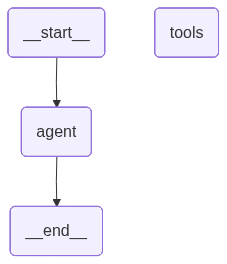

In [18]:
Image(graph_compiled.get_graph().draw_mermaid_png())

In [19]:
output = graph_compiled.invoke({'messages': [
    ('user', 'Write a simple report on how to use AI for productivity.')
]})

output

{'messages': [HumanMessage(content='Write a simple report on how to use AI for productivity.', additional_kwargs={}, response_metadata={}, id='1dbe65a3-1031-4214-a8c6-4ef6ecbf5c6f'),
  AIMessage(content='# Report on Using AI for Productivity\n\n## Introduction\nArtificial Intelligence (AI) has emerged as a transformative tool in various sectors, enhancing productivity and efficiency. This report outlines practical ways to leverage AI for improving productivity in personal and professional settings.\n\n## 1. Task Automation\nAI can automate repetitive tasks, allowing individuals and teams to focus on more strategic activities. Common applications include:\n\n- **Email Management**: AI tools can sort, prioritize, and respond to emails, reducing the time spent on inbox management.\n- **Scheduling**: AI-powered scheduling assistants can coordinate meetings by finding suitable times for all participants, eliminating back-and-forth communication.\n\n## 2. Data Analysis\nAI excels at processi

In [20]:
from IPython.display import Markdown

Markdown(output['messages'][-1].content)

# Report on Using AI for Productivity

## Introduction
Artificial Intelligence (AI) has emerged as a transformative tool in various sectors, enhancing productivity and efficiency. This report outlines practical ways to leverage AI for improving productivity in personal and professional settings.

## 1. Task Automation
AI can automate repetitive tasks, allowing individuals and teams to focus on more strategic activities. Common applications include:

- **Email Management**: AI tools can sort, prioritize, and respond to emails, reducing the time spent on inbox management.
- **Scheduling**: AI-powered scheduling assistants can coordinate meetings by finding suitable times for all participants, eliminating back-and-forth communication.

## 2. Data Analysis
AI excels at processing and analyzing large datasets quickly. This capability can be utilized in various ways:

- **Business Intelligence**: AI tools can analyze sales data, customer behavior, and market trends, providing insights that inform decision-making.
- **Predictive Analytics**: By identifying patterns in historical data, AI can forecast future trends, helping businesses to plan effectively.

## 3. Enhanced Communication
AI can improve communication within teams and with clients:

- **Chatbots**: Implementing AI chatbots on websites can provide instant customer support, answering frequently asked questions and freeing up human resources for more complex inquiries.
- **Language Translation**: AI translation tools can facilitate communication in multilingual environments, breaking down language barriers.

## 4. Personal Productivity Tools
Individuals can use AI-driven applications to enhance their productivity:

- **Virtual Assistants**: Tools like Siri, Google Assistant, and Alexa can help manage tasks, set reminders, and provide information quickly.
- **Focus and Time Management**: AI applications can analyze work patterns and suggest optimal times for focused work, breaks, and task prioritization.

## 5. Learning and Development
AI can support continuous learning and skill development:

- **Personalized Learning**: AI platforms can tailor educational content to individual learning styles and paces, making training more effective.
- **Skill Assessment**: AI tools can evaluate skills and recommend resources for improvement, helping employees to grow in their roles.

## Conclusion
Integrating AI into daily workflows can significantly enhance productivity by automating tasks, providing valuable insights, improving communication, and supporting personal development. As AI technology continues to evolve, its potential to drive efficiency and effectiveness in various domains will only increase. Organizations and individuals should explore and adopt AI solutions that align with their specific needs to maximize productivity.

## Recommendations
- **Identify Repetitive Tasks**: Assess daily activities to identify tasks that can be automated.
- **Invest in AI Tools**: Research and invest in AI applications that suit your personal or organizational needs.
- **Train Employees**: Provide training on how to effectively use AI tools to ensure maximum benefit.
- **Monitor and Adjust**: Regularly evaluate the impact of AI on productivity and make adjustments as necessary to optimize its use.